# Aula 13 — Segmentação e clusterização

Nas Aulas 11 e 12 o computador aprendeu com **respostas conhecidas**: cada post do treino já vinha com a taxa de engajamento real ou com o rótulo "viralizou". Isso é aprendizado **supervisionado**.

Hoje não há resposta. A gente entrega uma tabela de clientes e pergunta: "existem grupos naturais aqui? clientes que se parecem entre si e são diferentes dos outros?". O computador **agrupa sozinho** e o trabalho de interpretar cada grupo, e decidir se ele faz sentido, é seu. Isso é aprendizado **não-supervisionado**, e o método mais usado se chama **clusterização** (ou *clustering*).

É a última aula do bloco de aprendizado de máquina. Depois dela vem o **Projeto 3**, um case que junta regressão, classificação e segmentação na sua coleta de rede social, e vale o dobro.

## 1. Preparando o ambiente

`pandas`, `scikit-learn` e `matplotlib`, iguais às Aulas 11 e 12. Dentro da pasta `aulas/13-segmentacao-clusterizacao/`:

No Windows (Prompt de Comando ou Terminal integrado do VS Code):

```cmd
uv venv .venv
uv pip install -r requirements.txt
```

No Mac (Terminal), os mesmos comandos. Se o `uv` não funcionar, `pip install -r requirements.txt` com o ambiente ativado.

## 2. A base de clientes

`dados/clientes.csv` é uma base **sintética** (inventada, não é coleta real) de 1.210 clientes de uma loja fictícia. Cada linha é um cliente, descrito por como ele se comporta: há quanto tempo é cliente, quanto comprou e gastou no último ano, se usa cupom, se abre e-mail de marketing, se abre chamado no suporte.

**Não existe coluna "segmento".** É exatamente isso que a gente quer descobrir. O arquivo `exemplos/gerar_clientes.py` mostra como a base foi construída (há quatro perfis embutidos de propósito), mas na aula a gente finge que não sabe disso e deixa o algoritmo encontrar os grupos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clientes = pd.read_csv("dados/clientes.csv")
print(f"{len(clientes)} clientes, {clientes.shape[1]} colunas")
clientes.head()

1210 clientes, 13 colunas


,cliente_id,meses_como_cliente,compras_12m,dias_desde_ultima_compra,gasto_total_12m,ticket_medio,categoria_preferida,canal_preferido,pct_compras_com_cupom,abriu_email_mkt_pct,visitas_site_mes,chamados_suporte_12m,devolucoes_12m
0,C00001,64,15,35,8850,452,beleza,app,0.144,0.470,11,3,1
1,C00002,33,20,44,2130,105,moda,app,0.533,0.547,10,3,4
2,C00003,70,6,31,4600,458,eletronicos,site,0.093,0.582,30,0,1
3,C00004,22,14,1,6460,404,casa,site,0.106,0.516,15,2,0
4,C00005,31,9,41,1460,101,eletronicos,app,0.937,0.305,7,3,2


In [2]:
# um resumo rápido das colunas numéricas
clientes.describe().round(1)

,meses_como_cliente,compras_12m,dias_desde_ultima_compra,gasto_total_12m,ticket_medio,pct_compras_com_cupom,abriu_email_mkt_pct,visitas_site_mes,chamados_suporte_12m,devolucoes_12m
count,1210.0,1210.0,1210.0,1210.0,1210.0,1210.0,1210.0,1210.0,1210.0,1210.0
mean,27.6,10.9,58.7,2798.4,195.8,0.4,0.3,8.6,2.2,1.8
std,19.3,8.3,60.7,3010.1,129.6,0.3,0.2,6.9,2.2,1.9
min,1.0,0.0,1.0,60.0,30.0,0.0,0.0,0.0,0.0,0.0
25%,7.0,3.0,18.0,570.0,98.0,0.1,0.1,3.0,1.0,0.0
50%,28.0,11.0,34.0,1495.0,155.5,0.3,0.3,6.0,1.0,1.0
75%,42.0,18.0,77.0,4250.0,273.8,0.6,0.5,14.0,3.0,3.0
max,84.0,32.0,318.0,13310.0,681.0,1.0,1.0,33.0,12.0,9.0


**O que observar:** as colunas estão em **escalas completamente diferentes**. `gasto_total_12m` chega a 16 mil; `pct_compras_com_cupom` vai de 0 a 1; `meses_como_cliente` fica na casa das dezenas. A Seção 3 explica por que isso é um problema e como resolver.

## 3. Padronização: colocar tudo na mesma régua

A clusterização mede **distância** entre clientes: dois clientes são "parecidos" se a distância entre eles é pequena. Mas distância soma as diferenças de todas as colunas, e uma diferença de 5.000 em `gasto_total_12m` domina completamente uma diferença de 0,3 em `pct_compras_com_cupom`, mesmo que a segunda seja proporcionalmente enorme.

A solução é **padronizar**: transformar cada coluna para ter média 0 e desvio 1. Depois disso, "estar 2 desvios acima da média" pesa igual em qualquer coluna. O `StandardScaler` do scikit-learn faz isso.

Vamos usar só as colunas **numéricas** (`categoria_preferida` e `canal_preferido` são texto; para simplificar, ficam de fora hoje).

In [3]:
from sklearn.preprocessing import StandardScaler

# só colunas numéricas, sem o id
colunas_num = clientes.select_dtypes("number").columns.tolist()
print("Colunas usadas:", colunas_num)

X = clientes[colunas_num]
X_padronizado = StandardScaler().fit_transform(X)  # média 0, desvio 1 em cada coluna

# conferindo: cada coluna agora tem média ~0 e desvio ~1
pd.DataFrame(X_padronizado, columns=colunas_num).describe().round(2).loc[["mean", "std"]]

Colunas usadas: ['meses_como_cliente', 'compras_12m', 'dias_desde_ultima_compra', 'gasto_total_12m', 'ticket_medio', 'pct_compras_com_cupom', 'abriu_email_mkt_pct', 'visitas_site_mes', 'chamados_suporte_12m', 'devolucoes_12m']


,meses_como_cliente,compras_12m,dias_desde_ultima_compra,gasto_total_12m,ticket_medio,pct_compras_com_cupom,abriu_email_mkt_pct,visitas_site_mes,chamados_suporte_12m,devolucoes_12m
mean,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 4. KMeans: agrupando em `k` clusters

O **KMeans** funciona assim: você diz quantos grupos quer (`k`), e o algoritmo escolhe `k` "centros", coloca cada cliente no centro mais próximo, recalcula os centros como a média dos clientes de cada grupo, e repete até parar de mudar.

Vamos começar chutando `k=4` só para ver o formato da saída. A Seção 5 mostra como escolher `k` direito.

`n_init=10` roda o algoritmo 10 vezes com centros iniciais diferentes e fica com o melhor; `random_state=42` deixa reproduzível.

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
grupos = kmeans.fit_predict(X_padronizado)  # devolve um número de cluster (0 a 3) por cliente

clientes["cluster"] = grupos  # guarda o cluster de cada cliente na tabela

clientes["cluster"].value_counts().sort_index()

cluster
0    302
1    359
2    331
3    218
Name: count, dtype: int64

**O que observar:** cada cliente ganhou um rótulo de 0 a 3. Esses números não têm ordem nem significado, são só etiquetas; "cluster 2" não é melhor que "cluster 1". Os grupos têm tamanhos diferentes, o que é normal. O que falta agora é (a) confirmar que 4 é um bom número de grupos e (b) descobrir o que cada grupo significa.

## 5. Escolhendo `k`: cotovelo e silhueta

Dois indicadores ajudam a decidir quantos grupos pedir:

- **Inércia (curva do cotovelo):** a soma das distâncias de cada cliente ao centro do seu grupo. Sempre cai quando `k` aumenta (com `k` = número de clientes, a inércia é zero). A gente procura o "cotovelo": o ponto a partir do qual aumentar `k` quase não reduz mais a inércia.
- **Silhueta:** mede, de -1 a 1, o quão bem separado cada cliente está do grupo vizinho mais próximo. Perto de 1 é ótimo, perto de 0 é ambíguo. A gente escolhe o `k` com a maior silhueta média.

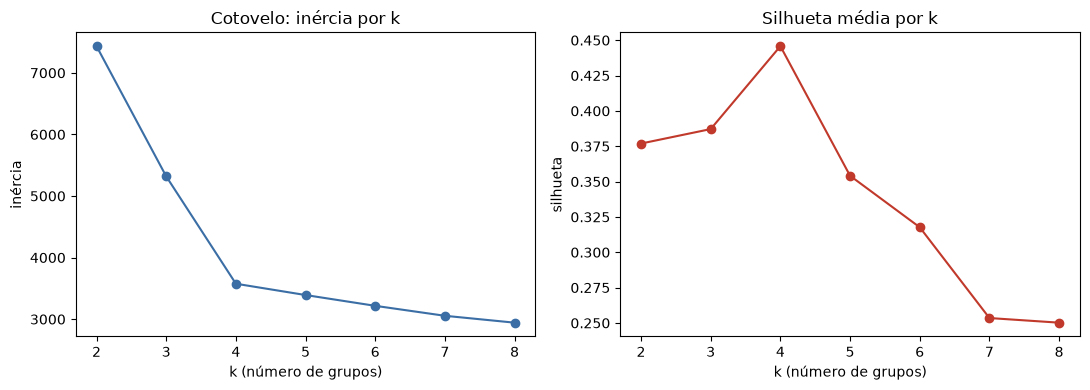

k=2: silhueta 0.377
k=3: silhueta 0.387
k=4: silhueta 0.446
k=5: silhueta 0.354
k=6: silhueta 0.318
k=7: silhueta 0.253
k=8: silhueta 0.250


In [5]:
from sklearn.metrics import silhouette_score

inercias = []
silhuetas = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_padronizado)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_padronizado, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inercias, marker="o", color="#3b6ea5")
ax1.set_title("Cotovelo: inércia por k")
ax1.set_xlabel("k (número de grupos)"); ax1.set_ylabel("inércia")

ax2.plot(list(ks), silhuetas, marker="o", color="#c0392b")
ax2.set_title("Silhueta média por k")
ax2.set_xlabel("k (número de grupos)"); ax2.set_ylabel("silhueta")

fig.tight_layout()
plt.show()

for k, s in zip(ks, silhuetas):
    print(f"k={k}: silhueta {s:.3f}")

**O que observar:** a inércia despenca até `k=4` e depois a curva "dobra" e fica quase reta (o cotovelo). A silhueta é mais alta em `k=4`. Os dois indicadores apontam para o mesmo número, o que dá confiança. Nem sempre é assim tão limpo: às vezes o cotovelo é suave e a silhueta empata entre dois valores, e aí a escolha vira uma decisão sua, que você justifica. Vamos fixar `k=4`.

## 6. Perfilando os clusters: o que cada grupo é

Um cluster só serve para alguma coisa depois que você consegue descrevê-lo em palavras. A forma mais direta é olhar a **média de cada coluna dentro de cada grupo** e comparar com a média geral.

In [6]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clientes["cluster"] = kmeans.fit_predict(X_padronizado)

# média de cada coluna, por cluster (nos valores ORIGINAIS, não nos padronizados, para ler melhor)
perfil = clientes.groupby("cluster")[colunas_num].mean().round(1)
perfil

,meses_como_cliente,compras_12m,dias_desde_ultima_compra,gasto_total_12m,ticket_medio,pct_compras_com_cupom,abriu_email_mkt_pct,visitas_site_mes,chamados_suporte_12m,devolucoes_12m
cluster,,,,,,,,,,
0,4.4,3.0,61.8,428.6,166.2,0.2,0.1,3.1,0.6,0.5
1,45.9,18.6,18.7,6800.6,347.7,0.1,0.6,15.2,1.1,0.7
2,22.1,15.6,27.6,1973.1,89.2,0.7,0.4,10.8,2.6,2.5
3,38.0,1.9,167.4,743.4,148.4,0.5,0.1,2.1,5.5,4.3


**O que observar:** cada linha é um grupo, cada coluna uma característica. Leia comparando os grupos entre si:

- Um grupo tem `meses_como_cliente` baixo, poucas `compras_12m` e `gasto_total_12m` baixo: são **clientes novos ou pouco engajados**.
- Um grupo tem tempo de casa alto, muitas compras, gasto alto, cupom baixo e abre bastante e-mail: são **clientes fiéis de alto valor**.
- Um grupo tem `ticket_medio` baixo mas `pct_compras_com_cupom` altíssimo: são **caçadores de promoção**.
- Um grupo tem tempo de casa alto mas `dias_desde_ultima_compra` enorme, `chamados_suporte_12m` alto e `devolucoes_12m` alto: são clientes **em risco de churn** (parando de comprar, com atrito).

O algoritmo não deu esses nomes. Ele só separou os clientes por semelhança de comportamento. **Você** lê as médias e traduz para termos de negócio.

## 7. Dando nome aos grupos

Traduzir cada cluster num rótulo curto deixa o resultado utilizável por quem não roda código. O nome sai da leitura da Seção 6; ajuste os números do cluster conforme saiu na sua execução (a etiqueta 0, 1, 2, 3 pode cair em ordem diferente).

In [7]:
# ajuste este dicionário conforme a leitura da tabela da Seção 6
nomes = {
    0: "novos / pouco engajados",
    1: "fiéis de alto valor",
    2: "caçadores de promoção",
    3: "em risco de churn",
}
clientes["segmento"] = clientes["cluster"].map(nomes)

clientes.groupby("segmento").agg(
    clientes=("cliente_id", "count"),
    gasto_medio=("gasto_total_12m", "mean"),
    compras_medias=("compras_12m", "mean"),
    dias_sem_comprar=("dias_desde_ultima_compra", "mean"),
    uso_cupom=("pct_compras_com_cupom", "mean"),
).round(2)

,clientes,gasto_medio,compras_medias,dias_sem_comprar,uso_cupom
segmento,,,,,
caçadores de promoção,331,1973.11,15.60,27.58,0.72
em risco de churn,218,743.39,1.89,167.41,0.50
fiéis de alto valor,359,6800.64,18.65,18.70,0.08
novos / pouco engajados,302,428.58,3.03,61.79,0.24


## 8. Visualizando os grupos

Um jeito de conferir os clusters "de olho" é jogar dois eixos num gráfico de dispersão e colorir por grupo. Como temos muitas colunas, o **PCA** ajuda: ele comprime todas as features em 2 eixos que preservam o máximo possível da variação, só para visualização.

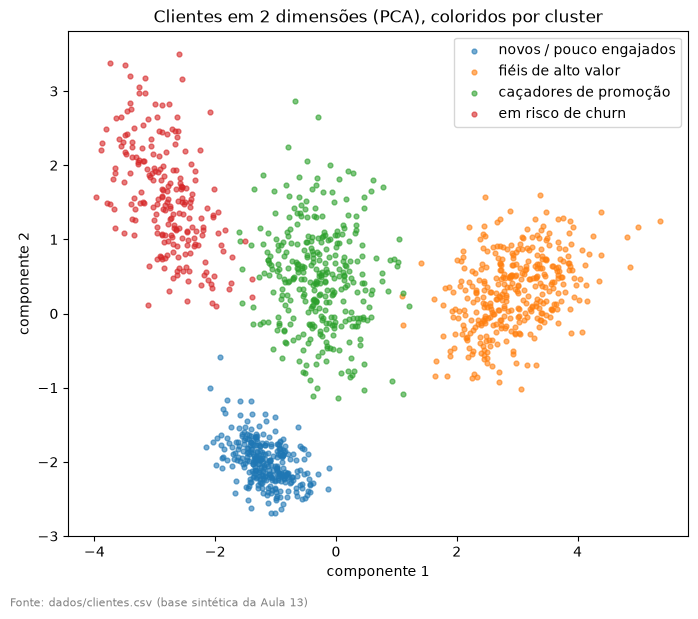

In [8]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=42).fit_transform(X_padronizado)

fig, ax = plt.subplots(figsize=(7, 6))
for c in sorted(clientes["cluster"].unique()):
    massa = clientes["cluster"] == c
    ax.scatter(coords[massa, 0], coords[massa, 1], s=12, alpha=0.6, label=nomes[c])
ax.set_title("Clientes em 2 dimensões (PCA), coloridos por cluster")
ax.set_xlabel("componente 1"); ax.set_ylabel("componente 2")
ax.legend()
fig.text(0.01, -0.02, "Fonte: dados/clientes.csv (base sintética da Aula 13)", fontsize=8, color="gray")
fig.tight_layout()
plt.show()

**O que observar:** os quatro grupos aparecem em regiões razoavelmente separadas do gráfico, com alguma sobreposição nas bordas (clientes que ficam "no meio" de dois perfis). Isso é esperado: segmento é uma simplificação útil, não uma divisão perfeita da realidade.

## 9. Os limites da clusterização

- **KMeans assume grupos "redondos" e de tamanho parecido.** Se os grupos reais têm formatos alongados ou densidades muito diferentes, o KMeans corta errado. Existem outros algoritmos (DBSCAN, hierárquico) para esses casos.
- **A escolha das features decide o resultado.** Se você tivesse incluído `categoria_preferida`, ou deixado `gasto_total_12m` de fora, os grupos seriam outros. Não existe "a" segmentação certa; existe a segmentação que responde à sua pergunta.
- **Padronizar não é opcional.** Sem `StandardScaler`, a coluna de maior escala domina e os grupos viram basicamente "quem gasta muito" e "quem gasta pouco".
- **Cluster não é verdade, é lente.** O algoritmo sempre devolve `k` grupos, mesmo que os dados não tenham grupo nenhum. A silhueta baixa e um perfil que não faz sentido de negócio são os sinais de que a segmentação não está capturando nada real.

## 10. Quando der errado

- **Esqueci de padronizar.** Os clusters saem dominados por uma coluna só (a de maior escala). Rode `StandardScaler().fit_transform(X)` antes do KMeans, sempre.
- **Silhueta baixa em todo `k` (abaixo de ~0,2).** Os dados podem não ter estrutura de grupo, ou as features escolhidas não separam nada. Reveja quais colunas entraram.
- **`ValueError: could not convert string to float`.** Sobrou coluna de texto no `X`. Use `select_dtypes("number")` ou converta as categóricas antes.
- **`ValueError: Input contains NaN`.** Valor ausente no `X`. Decida: `X.dropna()` (perde linhas) ou `X.fillna(X.median())`, e registre.
- **Os números dos clusters mudam entre execuções.** Normal: as etiquetas 0/1/2/3 são arbitrárias. Fixe `random_state=42` e `n_init=10` para o resultado ser estável, e mapeie os números para nomes toda vez pela leitura do perfil, não decorando "cluster 2 = fiéis".
- **`ModuleNotFoundError`.** Ambiente não criado. `uv venv .venv` e `uv pip install -r requirements.txt` dentro da pasta `aulas/13-segmentacao-clusterizacao/`.

## 11. Prática: faça agora — Projeto 3 (case, peso 2)

Abra `exercicios/exercicio-13-segmentacao-clusterizacao.ipynb`. Ele é o **Projeto 3**, o case que fecha o bloco de aprendizado de máquina e **vale o dobro de um projeto normal**. Na sua coleta de rede social, você vai:

- **criar e justificar uma variável contínua** e treinar uma regressão para ela (Aula 11);
- **criar e justificar o rótulo "viralizou"** por um corte e treinar um classificador (Aula 12);
- **segmentar** posts, autores ou hashtags e descrever cada segmento com um número (hoje).

O enunciado completo, o README a preencher e o checklist estão no notebook do exercício.